Integrating OpenAI LLM with a Simple Function Call. 

In [31]:
# Import PythinNative packages
import os
import keyboard
from dotenv import load_dotenv

from typing import TypedDict, Literal
from IPython.display import Image, display

# Import LangGraph Lib
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, AnyMessage

# Import OpenAI Lib
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [32]:
# Chat with OpenAI 

chat_chain = []

user_prompt = HumanMessage(content="Hello!!", name='User')
chat_chain.append(user_prompt)

chat_llm = ChatOpenAI(model='gpt-4o')
ai_message = chat_llm.invoke(chat_chain)
chat_chain.append(AIMessage(content=ai_message.content, name='Assistant'))


In [33]:
# Define a Multiply Tool function
# Bind Tool with LLM

chat_llm_with_tools = ''

def multiply(num1: int, num2: int) -> int:
    return(num1 * num2)

chat_llm_with_tools = chat_llm.bind_tools([multiply])

In [34]:
# Call the LLM with Tools

chat_chain.append(HumanMessage(content="Multiply 2 and 3", name='User'))
ai_message = chat_llm_with_tools.invoke(chat_chain)
ai_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_n7yXEP8sKIaBaIfrX49xShhH', 'function': {'arguments': '{"num1":2,"num2":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 73, 'total_tokens': 92, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'id': 'chatcmpl-BzGJaoxg5egRtldl6bcMLR2Di9Hf3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d9aa4658-8508-44f2-9c0a-6db8d4748124-0', tool_calls=[{'name': 'multiply', 'args': {'num1': 2, 'num2': 3}, 'id': 'call_n7yXEP8sKIaBaIfrX49xShhH', 'type': 'tool_call'}], usage_metadata={'input_tokens': 73, 'output_tokens': 19, 'total_tokens': 92, 'input_token_details': {'audio': 0

In [60]:
# Defined Graph State

class State(TypedDict):
    chat_msg: list[AnyMessage]

def llm_with_tools(state: State):
    chat_content = state['chat_msg']
    print(chat_content)
    ai_msg = chat_llm_with_tools.invoke(chat_content)
    print(ai_msg)

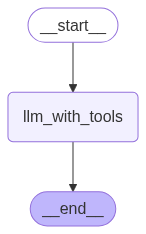

In [62]:
# Set up LannGraph Flow

graph_builder = StateGraph(state_schema=State)

# Add Nodes
graph_builder.add_node("llm_with_tools", llm_with_tools)

# Add Edges
graph_builder.add_edge(START, "llm_with_tools")
graph_builder.add_edge("llm_with_tools", END)

# Compile Graph
graph = graph_builder.compile()

# Visualize Graph
# Visualize Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [63]:
# Invoke Lang Graph 

graph.invoke({'chat_msg': [HumanMessage(content="Multiply 5 and 4")]})


[HumanMessage(content='Multiply 5 and 4', additional_kwargs={}, response_metadata={})]
content='' additional_kwargs={'tool_calls': [{'id': 'call_snouqsJ03QRjw4v9Q0L3E0As', 'function': {'arguments': '{"num1":5,"num2":4}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 48, 'total_tokens': 67, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'id': 'chatcmpl-BzGfk5V1WKvQxvvxy3XLq0UHnVIA8', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--5c756ffa-bc13-4e87-be28-935032101a18-0' tool_calls=[{'name': 'multiply', 'args': {'num1': 5, 'num2': 4}, 'id': 'call_snouqsJ03QRjw4v9Q0L3E0As', 'type': 'tool_call'}] usage_metadata={'input_tokens': 48, 'ou

{'chat_msg': [HumanMessage(content='Multiply 5 and 4', additional_kwargs={}, response_metadata={})]}